# 项目：用线性回归预测房价数据

## 分析目标

此数据分析报告的目的是，基于已有的房屋销售价格，以及有关该房屋的属性，进行线性回归分析，从而利用得到的线性回归模型，能对以下未知售价的房屋根据属性进行价格预测：

面积为6500平方英尺，有4个卧室、2个厕所，总共2层，不位于主路，无客人房，带地下室，有热水器，没有空调，车位数为2，位于城市首选社区，简装修。

## 简介

数据集`house_price.csv`记录了超过五百栋房屋的交易价格，以及房屋的相关属性信息，包括房屋面积、卧室数、厕所数、楼层数、是否位于主路、是否有客房，等等。

`house_price.csv`每列的含义如下：
- price：房屋出售价格
- area：房屋面积，以平方英尺为单位
- bedrooms：卧室数
- bathrooms：厕所数
- stories：楼层数
- mainroad：是否位于主路
   - yes  是
   - no	  否
- guestroom：是否有客房
   - yes  是
   - no	  否
- basement：是否有地下室
   - yes  是
   - no	  否
- hotwaterheating：是否有热水器
   - yes  是
   - no	  否
- airconditioning：是否有空调
   - yes  是
   - no	  否
- parking：车库容量，以车辆数量为单位
- prefarea：是否位于城市首选社区
   - yes  是
   - no	  否
- furnishingstatus：装修状态
   - furnished       精装
   - semi-furnished	 简装
   - unfurnished     毛坯

In [1]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
original_house_price =pd.read_csv('house_price.csv')
original_house_price.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 评估和清理数据


为了区分开经过清理的数据和原始的数据，我们创建新的变量`cleaned_house_price`，让它为`original_house_price`复制出的副本。我们之后的清理步骤都将被运用在`cleaned_house_price`上。

In [3]:
cleaned_data = original_house_price.copy()

### 数据整齐度

In [4]:
cleaned_data.head(19)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


上表可以看出，数据符合每个变量为一列，每个样本为一行的格式。

### 数据干净度

In [5]:
cleaned_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


根据上表可以看出数据没有缺失值，数据类型方面，我们已知`mainroad`（是否位于主路）、`guestroom`（是否有客房）、`basement`（是否有地下室）、`hotwaterheating`（是否有热水器）、`airconditioning`（是否有空调）、`prefarea`（是否位于城市首选社区）、`furnishingstatus`（装修状态）都是分类数据，可以把数据类型都转换为Category。

In [6]:
cleaned_data['mainroad'] = cleaned_data['mainroad'].astype("category")
cleaned_data['guestroom'] = cleaned_data['guestroom'].astype("category")
cleaned_data['basement'] = cleaned_data['basement'].astype("category")
cleaned_data['hotwaterheating'] = cleaned_data['hotwaterheating'].astype("category")
cleaned_data['airconditioning'] = cleaned_data['airconditioning'].astype("category")
cleaned_data['prefarea'] = cleaned_data['prefarea'].astype("category")
cleaned_data['furnishingstatus'] = cleaned_data['furnishingstatus'].astype("category")

In [7]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   price             545 non-null    int64   
 1   area              545 non-null    int64   
 2   bedrooms          545 non-null    int64   
 3   bathrooms         545 non-null    int64   
 4   stories           545 non-null    int64   
 5   mainroad          545 non-null    category
 6   guestroom         545 non-null    category
 7   basement          545 non-null    category
 8   hotwaterheating   545 non-null    category
 9   airconditioning   545 non-null    category
 10  parking           545 non-null    int64   
 11  prefarea          545 non-null    category
 12  furnishingstatus  545 non-null    category
dtypes: category(7), int64(6)
memory usage: 30.3 KB


从输出结果看不存在缺失值

#### 处理重复数据

In [8]:
cleaned_data['mainroad'].value_counts()

mainroad
yes    468
no      77
Name: count, dtype: int64

In [9]:
cleaned_data['guestroom'].value_counts()

guestroom
no     448
yes     97
Name: count, dtype: int64

In [10]:
cleaned_data['basement'].value_counts()

basement
no     354
yes    191
Name: count, dtype: int64

In [11]:
cleaned_data['hotwaterheating'].value_counts()

hotwaterheating
no     520
yes     25
Name: count, dtype: int64

In [12]:
cleaned_data['airconditioning'].value_counts()

airconditioning
no     373
yes    172
Name: count, dtype: int64

In [13]:
cleaned_data['prefarea'].value_counts()

prefarea
no     417
yes    128
Name: count, dtype: int64

In [14]:
cleaned_data['furnishingstatus'].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

以上分类数据不存在一种变量由多个数值构成的情形。

#### 处理无效值或错误数据

In [15]:
cleaned_data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


数据并不存在异常值

## 探索数据

借助数据可视化，探索数值变量的分布，以及与房价存在相关性的变量，为后续的进一步分析提供方向。

### 房价分布

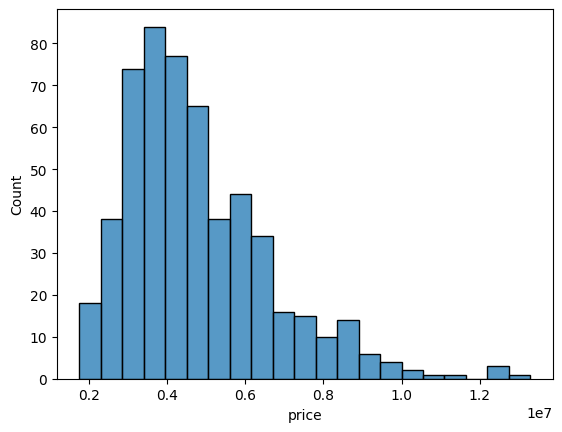

In [16]:
sns.histplot(cleaned_data, x="price" )
plt.show()

房价呈右偏态分布，说明数据集中的大多数房子价格中等，但有一些价格很高的极端值，使得均值被拉高。

### 面积分布

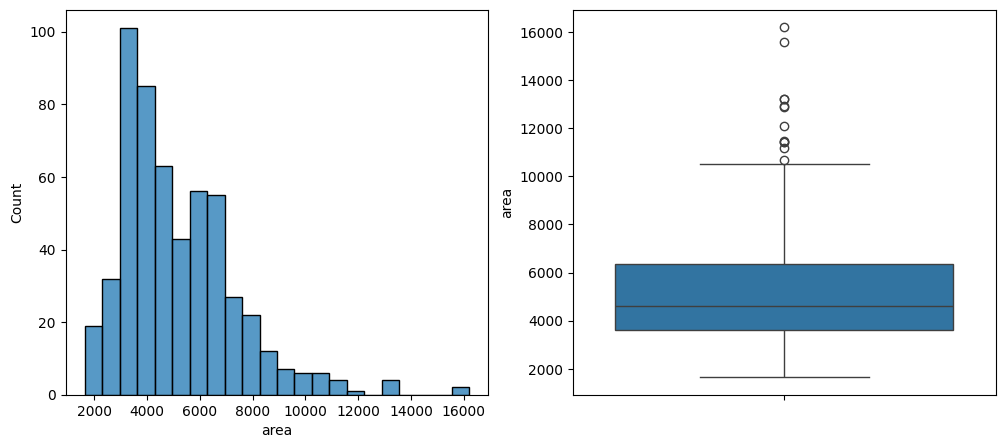

In [17]:
fig,axes = plt.subplots(1,2,figsize=(12,5))
sns.histplot(cleaned_data, x='area', ax = axes[0])
sns.boxplot(cleaned_data, y='area', ax = axes[1])
plt.show()

面积的分布与房价相似，也呈右偏态分布。

### 房价与面积的关系

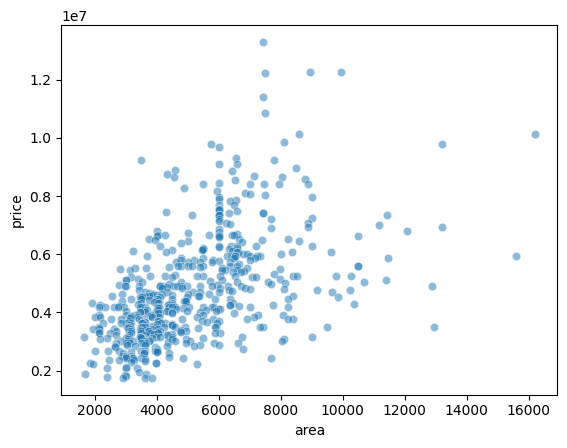

In [18]:
sns.scatterplot(cleaned_data, x='area', y='price',alpha = 0.5 )
plt.show()

从散点图来看，能大致看出一些正相关关系，但关系的强度需要后续通过计算相关性来得到。

### 卧室数与房价的关系

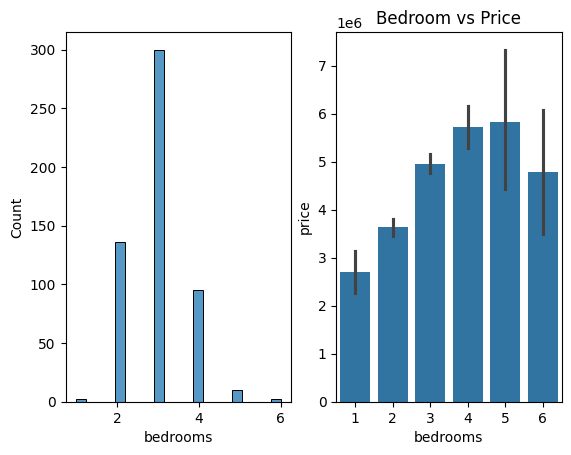

In [19]:
fig,axes = plt.subplots(1,2)
sns.histplot(x='bedrooms', data=cleaned_data , ax=axes[0])
sns.barplot(cleaned_data, x='bedrooms', y='price' , ax=axes[1])
plt.title('Bedroom vs Price')
plt.show()

此数据集中房子的卧室数范围为1-6个，其中大多房子有2-4个。1-4个卧室的房价正相关，当卧室数超过4个时，房价不一定更高

### 卫生间数与房价


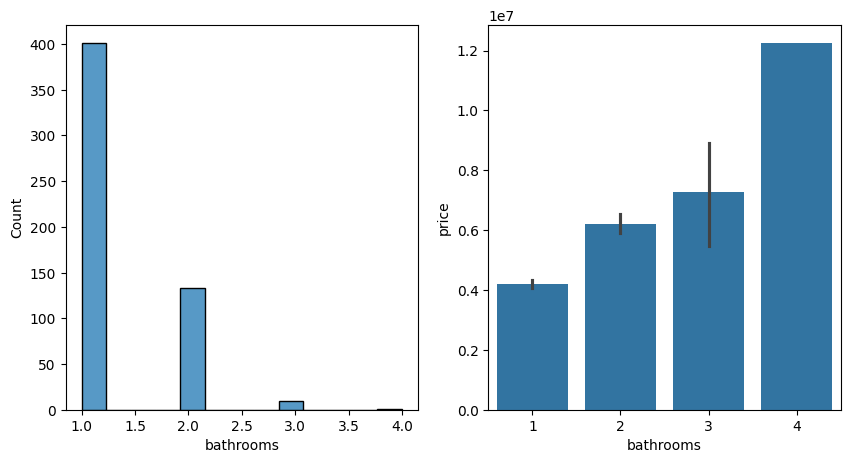

In [20]:
fig,axes = plt.subplots(1,2,figsize=(10,5))
sns.histplot(cleaned_data,x='bathrooms',ax=axes[0])
sns.barplot(data=cleaned_data,x='bathrooms',y='price',ax=axes[1])
plt.show()

数据集中房子洗手间数量最少1个，最多4个，其中为1个的数量最多。

从平均房价与洗手间数之间的柱状图来看，洗手间多的房子价格也相应高。

### 楼层数与房价

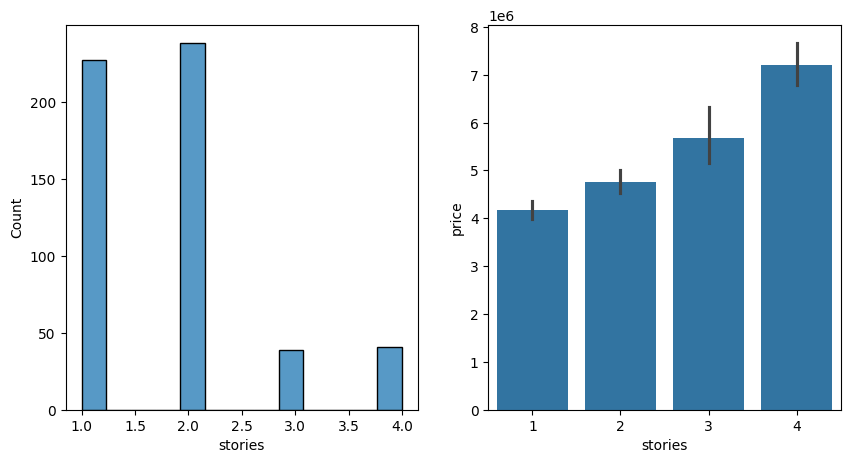

In [21]:
fig,axes = plt.subplots(1,2,figsize=(10,5))
sns.histplot(cleaned_data,x='stories',ax=axes[0])
sns.barplot(cleaned_data,x='stories',y='price',ax=axes[1])
plt.show()

层数为一层和2层的房屋数量最多，而超过3层的房屋数量较少。且房屋价格随层数增加而上升。

### 车库数与房价

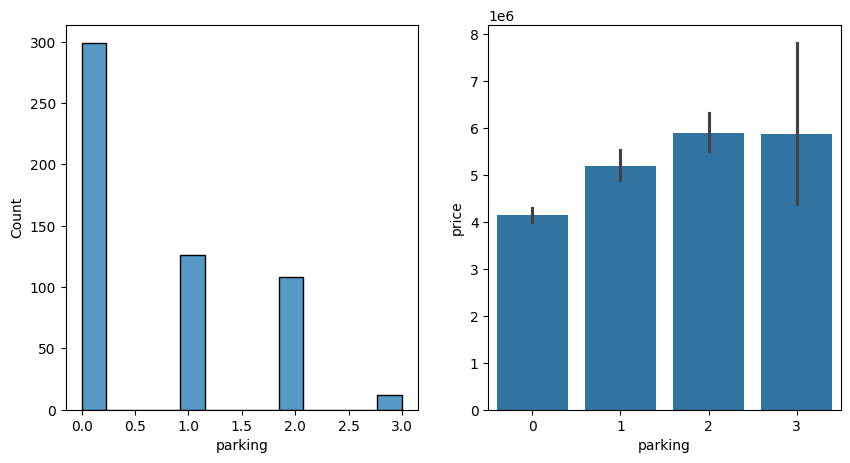

In [22]:
fig,axes = plt.subplots(1,2,figsize=(10,5))
sns.histplot(cleaned_data,x='parking',ax=axes[0])
sns.barplot(cleaned_data,x='parking',y='price',ax=axes[1])
plt.show()

### 是否在主路与房价

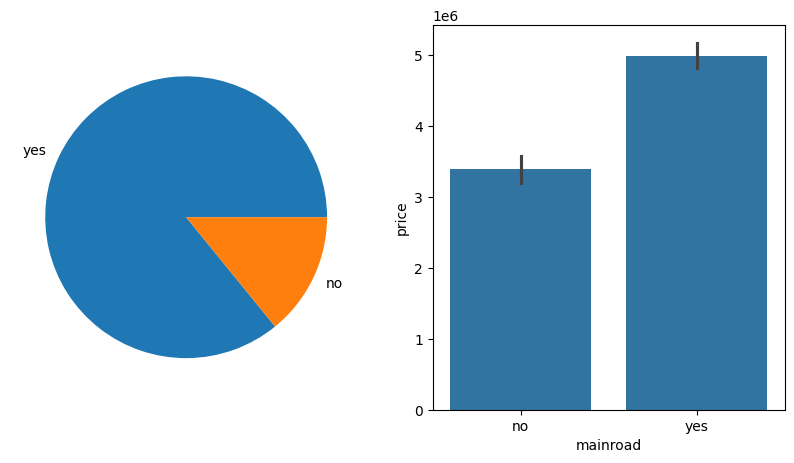

In [23]:
fig,axes = plt.subplots(1,2,figsize=(10,5))
mainroad_count = cleaned_data['mainroad'].value_counts()
mainroad_label = mainroad_count.index
axes[0].pie( mainroad_count, labels=mainroad_label)
sns.barplot(cleaned_data,x= 'mainroad', y='price' ,ax=axes[1])
plt.show()

层数为一层和2层的房屋数量最多，而超过3层的房屋数量较少。且房屋价格随层数增加而上升。

### 是否有客房的房子对房价影响

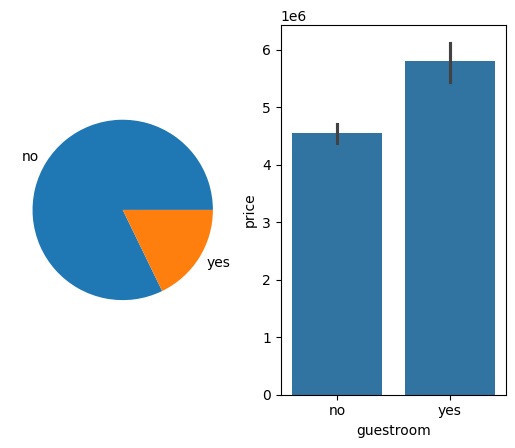

In [24]:
fig,axes = plt.subplots(1,2)
guestroom_count = cleaned_data['guestroom'].value_counts()
guestroom_lable = guestroom_count.index
axes[0].pie(guestroom_count, labels=guestroom_lable)
sns.barplot(cleaned_data, x='guestroom', y='price', ax=axes[1])
plt.show()

可以看出大多数房子是没有客房的，
从平均房价与楼层数之间的柱状图来看，有客人房的的房子价格也相应高。



### 是否有地下室对房价的影响

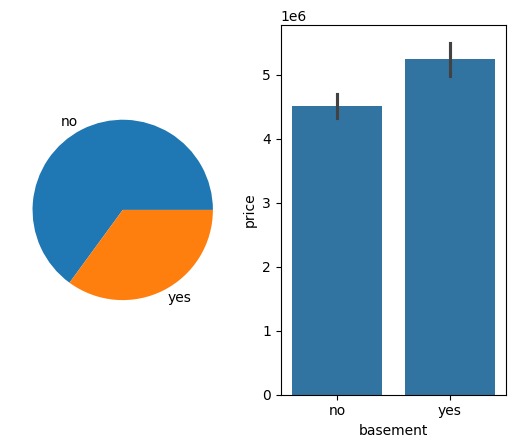

In [25]:
fig, axes= plt.subplots(1,2)
basement_count = cleaned_data['basement'].value_counts()
basement_label = basement_count.index
axes[0].pie(basement_count, labels=basement_label)
sns.barplot(cleaned_data, x='basement',y='price',ax=axes[1])
plt.show()  


此数据集中更多的房子没有地下室。

从平均房价与地下室之间的柱状图来看，有地下室的的房子价格也相应高。

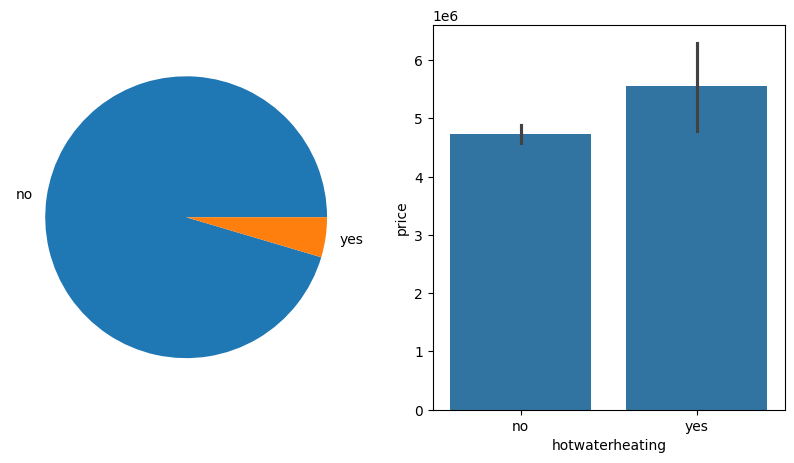

In [26]:
fig,axes = plt.subplots(1,2,figsize=(10,5))
hotwaterheating_count = cleaned_data['hotwaterheating'].value_counts()
hotwaterheating_label = hotwaterheating_count.index
axes[0].pie(hotwaterheating_count, labels=hotwaterheating_label)
sns.barplot(cleaned_data,x='hotwaterheating', y='price', ax=axes[1])
plt.show()

此数据集中更多的房子没有地下室。

从平均房价与地下室之间的柱状图来看，有地下室的的房子价格也相应高。

### 是否有空调与房价的关系

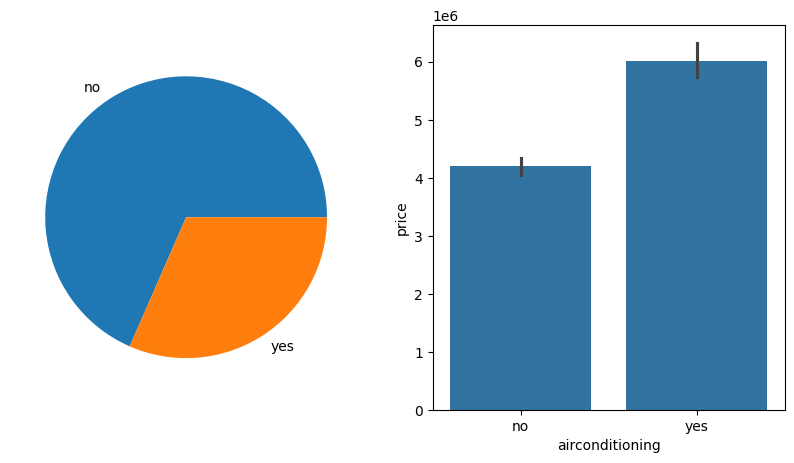

In [27]:
fig, axes= plt.subplots(1,2,figsize=(10,5))
airconditioning_count = cleaned_data['airconditioning'].value_counts()
airconditioning_lable = airconditioning_count.index
axes[0].pie(airconditioning_count, labels=airconditioning_lable)
sns.barplot( cleaned_data,x='airconditioning', y='price', ax=axes[1])
plt.show()


此数据集中更多的房子没有空调。

从平均房价与空调之间的柱状图来看，有空调的的房子价格也相应高。

### 是否位于城市首选社区与房价

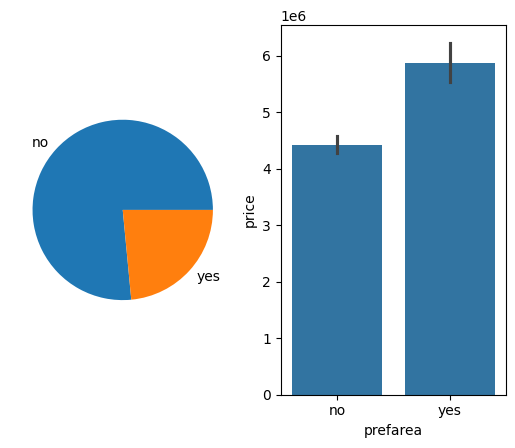

In [28]:
figure, axes = plt.subplots(1, 2)
prefarea_count = cleaned_data['prefarea'].value_counts()
prefarea_label = prefarea_count.index
axes[0].pie(prefarea_count, labels=prefarea_label)
sns.barplot(cleaned_data, x='prefarea', y='price', ax=axes[1])
plt.show()

此数据集中大部分房子不在城市首选社区。

从平均房价与城市首选社区之间的柱状图来看，在城市首选社区的的房子价格也相应高。

### 装修状态与房价

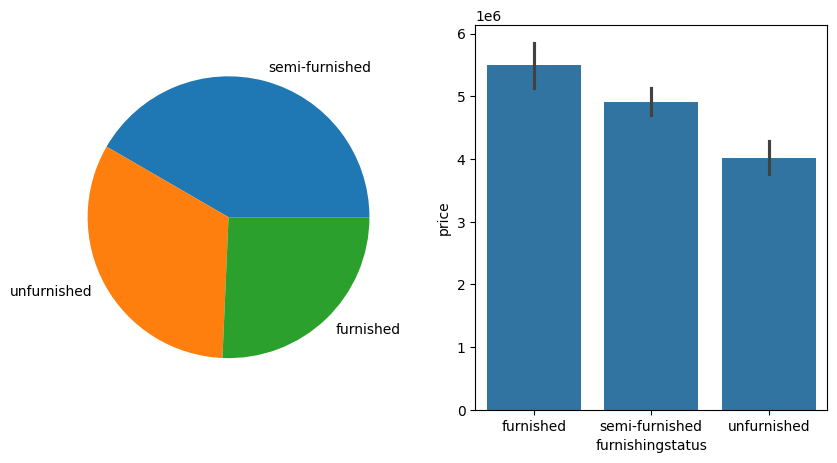

In [29]:
fig,axes = plt.subplots(1,2,figsize=(10,5))
furnishingstatus_count = cleaned_data['furnishingstatus'].value_counts()
frunishingstatus_lable = furnishingstatus_count.index
axes[0].pie(furnishingstatus_count,labels=frunishingstatus_lable)
sns.barplot(cleaned_data,x='furnishingstatus',y='price',ax=axes[1])
plt.show()


此数据集中简装和毛坯的房子较多，1/4左右房子为精装。

从平均房价与装修状态之间的柱状图来看，精装的房子价格高于简装，简装高于毛坯。

## 分析数据

    在分析步骤中，我们将利用`cleaned_house_price`的数据，进行线性回归分析，目标是得到一个可以根据房屋各个属性对价格进行预测的数学模型。

In [30]:
import statsmodels.api as sm

In [31]:
lr_price = cleaned_data.copy()

In [32]:
lr_price

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


由于数据里存在分类变量，无法直接建立线性回归模型。我们需要引入虚拟变量，也就是用0和1分别表示是否属于该分类。

In [33]:
lr_price = pd.get_dummies(lr_price, drop_first=True, columns=['mainroad', 'guestroom',
                                                   'basement', 'hotwaterheating',
                                                   'airconditioning','prefarea', 
                                                   'furnishingstatus'],dtype=int)

接下来，我们要把因变量和自变量划分出来。

因变量是`price`变量，因为我们进行线性回归的目的，是得到一个能根据其它可能对房屋价格有影响的变量，来预测销售价格的模型。

In [34]:
y = lr_price['price']

In [35]:
x = lr_price.drop('price', axis=1)

In [36]:
x.dtypes

area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
parking                            int64
mainroad_yes                       int64
guestroom_yes                      int64
basement_yes                       int64
hotwaterheating_yes                int64
airconditioning_yes                int64
prefarea_yes                       int64
furnishingstatus_semi-furnished    int64
furnishingstatus_unfurnished       int64
dtype: object

In [37]:
x.corr().abs()>0.8 # 查看相关性大于0.8的特征

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
area,True,False,False,False,False,False,False,False,False,False,False,False,False
bedrooms,False,True,False,False,False,False,False,False,False,False,False,False,False
bathrooms,False,False,True,False,False,False,False,False,False,False,False,False,False
stories,False,False,False,True,False,False,False,False,False,False,False,False,False
parking,False,False,False,False,True,False,False,False,False,False,False,False,False
mainroad_yes,False,False,False,False,False,True,False,False,False,False,False,False,False
guestroom_yes,False,False,False,False,False,False,True,False,False,False,False,False,False
basement_yes,False,False,False,False,False,False,False,True,False,False,False,False,False
hotwaterheating_yes,False,False,False,False,False,False,False,False,True,False,False,False,False
airconditioning_yes,False,False,False,False,False,False,False,False,False,True,False,False,False


从上表来看，不同变量之间相关系数绝对值小于0.8，相关性不强。

In [38]:
x = sm.add_constant(x) #添加常数项，计算截距
x

,const,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.0,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,1.0,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,1.0,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,1.0,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,1.0,7420,4,1,2,2,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1.0,3000,2,1,1,2,1,0,1,0,0,0,0,1
541,1.0,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1.0,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,1.0,2910,3,1,1,0,0,0,0,0,0,0,0,0


In [40]:
model = sm.OLS(y,x).fit()

In [42]:
print(model.summary().as_text())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     87.52
Date:                Wed, 16 Sep 2026   Prob (F-statistic):          9.07e-123
Time:                        10:04:18   Log-Likelihood:                -8331.5
No. Observations:                 545   AIC:                         1.669e+04
Df Residuals:                     531   BIC:                         1.675e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

当我们把显著区间设定为0.05时，以上结果的P值可以看出，模型认为以下因素对房屋价格没有显著性影响：卧室数、是否为简装房。此外，常数（表示线性方程的截距）的P值也很大，说明也没有显著影响。

可以把这些变量移除后，再次建立线性回归模型。

In [43]:
x=x.drop(['const','bedrooms','furnishingstatus_semi-furnished'],axis=1)

In [44]:
model = sm.OLS(y,x).fit()

In [45]:
print(model.summary().as_text())

                                 OLS Regression Results                                
Dep. Variable:                  price   R-squared (uncentered):                   0.957
Model:                            OLS   Adj. R-squared (uncentered):              0.956
Method:                 Least Squares   F-statistic:                              1088.
Date:                Wed, 16 Sep 2026   Prob (F-statistic):                        0.00
Time:                        10:11:48   Log-Likelihood:                         -8333.5
No. Observations:                 545   AIC:                                  1.669e+04
Df Residuals:                     534   BIC:                                  1.674e+04
Df Model:                          11                                                  
Covariance Type:            nonrobust                                                  
                                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------

根据各个自变量在线性回归方程中的系数来看，模型预测以下因素的增加会显著增加房屋价格：房屋面积、厕所数、楼层数、车库容量、位于主路、有客房、有地下室、有热水器、有空调、位于城市首选社区。

线性回归模型预测以下因素的增加会显著降低房屋价格：房屋未经装修，为毛坯房。

预测：面积为6500平方英尺，有4个卧室、2个厕所，总共2层，不位于主路，无客人房，带地下室，有热水器，没有空调，车位数为2，位于城市首选社区，简装修。

In [46]:
price_predict = pd.DataFrame({'area':[6500],'bedrooms':[4],'bathrooms':[2],
                                'stories': [2], 'mainroad': ['no'], 'guestroom': ['no'],
                                 'basement': ['yes'], 'hotwaterheating': ['yes'],
                                 'airconditioning': ['no'], 'parking': 2, 'prefarea': ['yes'],
                                 'furnishingstatus': ['semi-furnished']})
price_predict

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,6500,4,2,2,no,no,yes,yes,no,2,yes,semi-furnished


需要把分类变量的类型转换为Category，并且通过`categories`参数，让程序知道所有可能的分类值。这样做的原因是，预测数据包含的分类可能不全。需要确保引入虚拟变量的时候，不会漏掉某个或某些分类。

In [47]:
price_predict['mainroad'] = pd.Categorical(price_predict['mainroad'], categories=['no', 'yes'])
price_predict['guestroom'] = pd.Categorical(price_predict['guestroom'], categories=['no', 'yes'])
price_predict['basement'] = pd.Categorical(price_predict['basement'], categories=['no', 'yes'])
price_predict['hotwaterheating'] = pd.Categorical(price_predict['hotwaterheating'], categories=['no', 'yes'])
price_predict['airconditioning'] = pd.Categorical(price_predict['airconditioning'], categories=['no', 'yes'])
price_predict['prefarea'] = pd.Categorical(price_predict['prefarea'], categories=['no', 'yes'])
price_predict['furnishingstatus'] = pd.Categorical(price_predict['furnishingstatus'], categories=['furnished', 'semi-furnished', 'unfurnished'])

In [49]:
price_predict= pd.get_dummies(price_predict,drop_first=True,
                          columns=['mainroad','guestroom','basement',
                                   'hotwaterheating','airconditioning',
                                   'prefarea','furnishingstatus'],dtype=int)
price_predict.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,6500,4,2,2,2,0,0,1,1,0,1,1,0


In [52]:
price_predict = price_predict.drop(['bedrooms', 'furnishingstatus_semi-furnished'], axis=1) #删除模型中不需要的列

In [54]:
predict_value = model.predict(price_predict) #带入模型得出预测价格
predict_value

0    7.303754e+06
dtype: float64